<img style="float: left; margin: 30px 15px 15px 15px;" src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="500" height="250" /> 
    
    
# <font color='navy'> Modelo de Puntuación Crediticia

<font color='black'>

- Ivanna herrera Ibarra
- Ana Sofía Hinojosa Bale
- Luis Fernando Márquez Bañuelos

## <font color='royalblue'> Librerías

In [1]:
import shap
import optuna
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, plot_importance
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

## <font color='royalblue'> Benchmark

In [2]:
data = pd.read_csv('clean_train.csv')

data['Credit_Score'] = data['Credit_Score'].map({'Poor': 0, 'Standard': 1, 'Good': 2})
data = data.select_dtypes(include=['float64', 'int64', 'bool'])

target = 'Credit_Score'

In [3]:
X = data.copy()
X = X.drop(columns=[target])
y = data[target]

In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

              precision    recall  f1-score   support

           0       0.51      0.55      0.53      5799
           1       0.57      0.74      0.65     10635
           2       0.00      0.00      0.00      3566

    accuracy                           0.55     20000
   macro avg       0.36      0.43      0.39     20000
weighted avg       0.45      0.55      0.50     20000



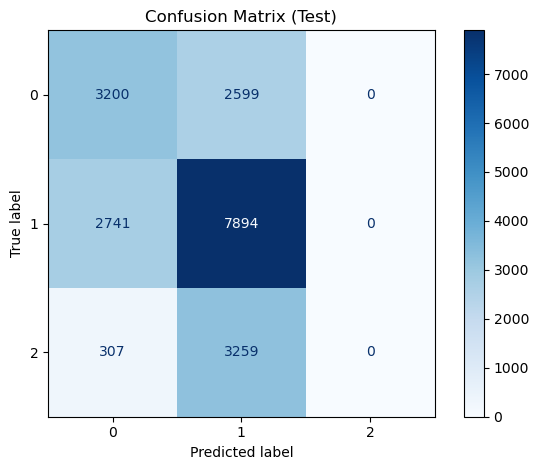

In [5]:
# Logistic Regression
model_log = LogisticRegression()
model_log.fit(X_train, y_train)

# Predictions
y_pred = model_log.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=[0, 1, 2],
    cmap='Blues'
)
plt.title('Confusion Matrix (Test)')

plt.tight_layout()
plt.show()

## <font color='royalblue'> Feature Selection

              precision    recall  f1-score   support

           0       0.77      0.70      0.73      5799
           1       0.77      0.78      0.77     10635
           2       0.62      0.69      0.65      3566

    accuracy                           0.74     20000
   macro avg       0.72      0.72      0.72     20000
weighted avg       0.74      0.74      0.74     20000



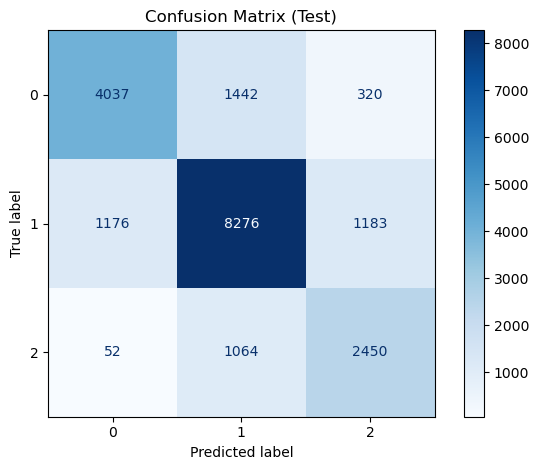

In [6]:
# We use a XGBoost model because is the most powerful model you can throw a this problem. This is mainly to help with determining the variable importance and 
# the weights for the credit score, but we also evaluate its performance to have a reference of how good the credit score can be.
model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=500,
    max_depth=8,
    learning_rate=0.01,
    min_child_weight=3,
    subsample=0.6,
    colsample_bytree=0.6,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=0
)

y_pred_xgb = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred_xgb))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=[0, 1, 2],
    cmap='Blues'
)
plt.title('Confusion Matrix (Test)')

plt.tight_layout()
plt.show()

### <font color = 'skyblue'> Feature Importance

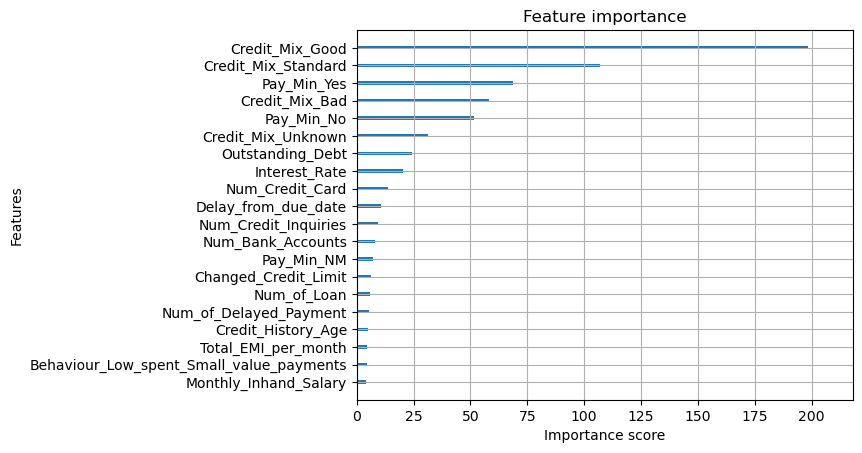

In [7]:
plot_importance(model, max_num_features=20, importance_type='gain', show_values=False);

### <font color = 'skyblue'> Shap Values

In [8]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

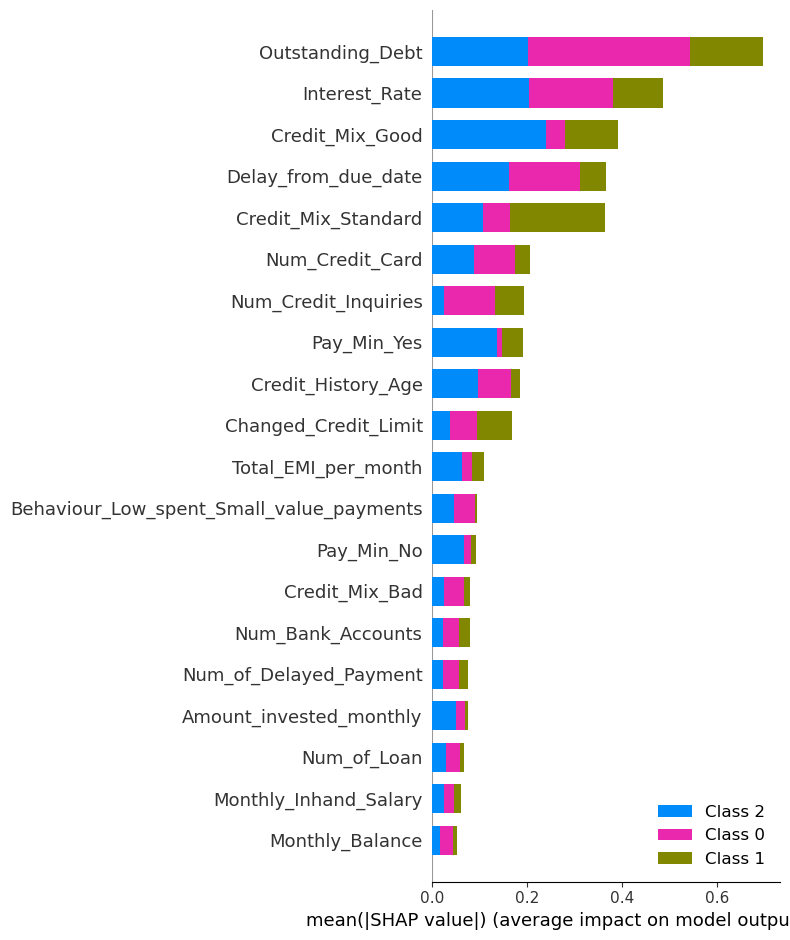

In [9]:
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20)

In [10]:
print("Verificando estructura de SHAP values...")
print(f"Tipo: {type(shap_values)}")

if isinstance(shap_values, list):
    print(f"Número de clases: {len(shap_values)}")
    print(f"Shape de cada clase: {shap_values[0].shape}")
    # Ya está en el formato correcto
    
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    print(f"Shape original: {shap_values.shape}")
    # Convertir a lista de arrays (transponer)
    shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
    print(f"Convertido a lista de {len(shap_values)} arrays")
    print(f"Shape de cada clase: {shap_values[0].shape}")

Verificando estructura de SHAP values...
Tipo: <class 'numpy.ndarray'>
Shape original: (20000, 56, 3)
Convertido a lista de 3 arrays
Shape de cada clase: (20000, 56)


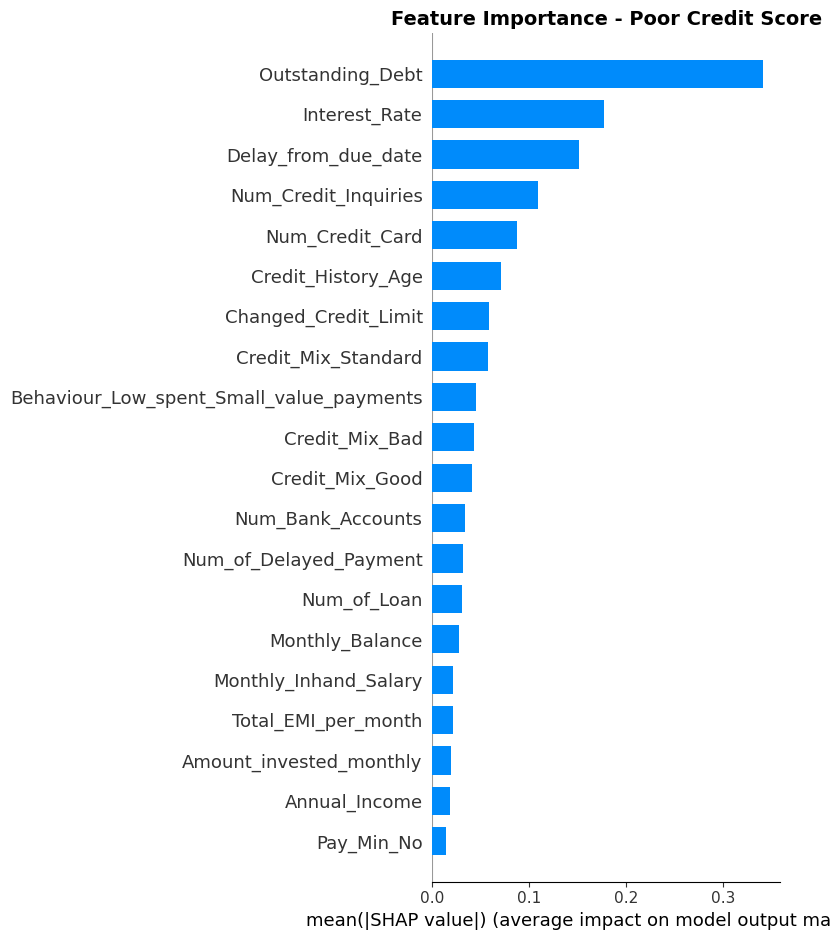

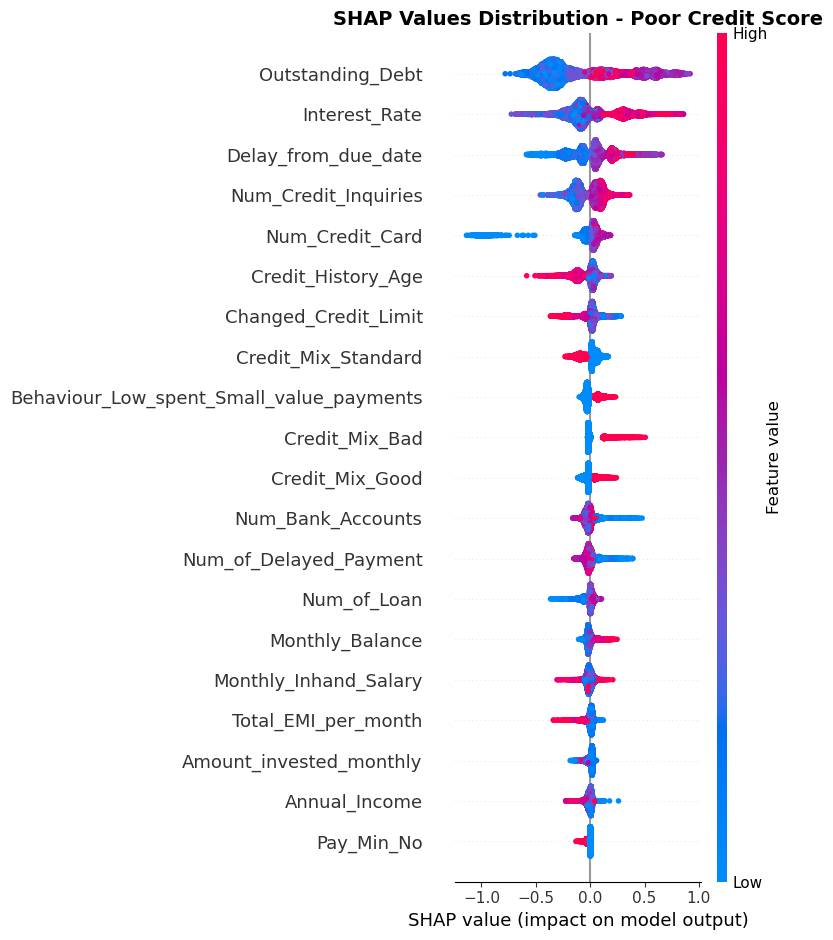

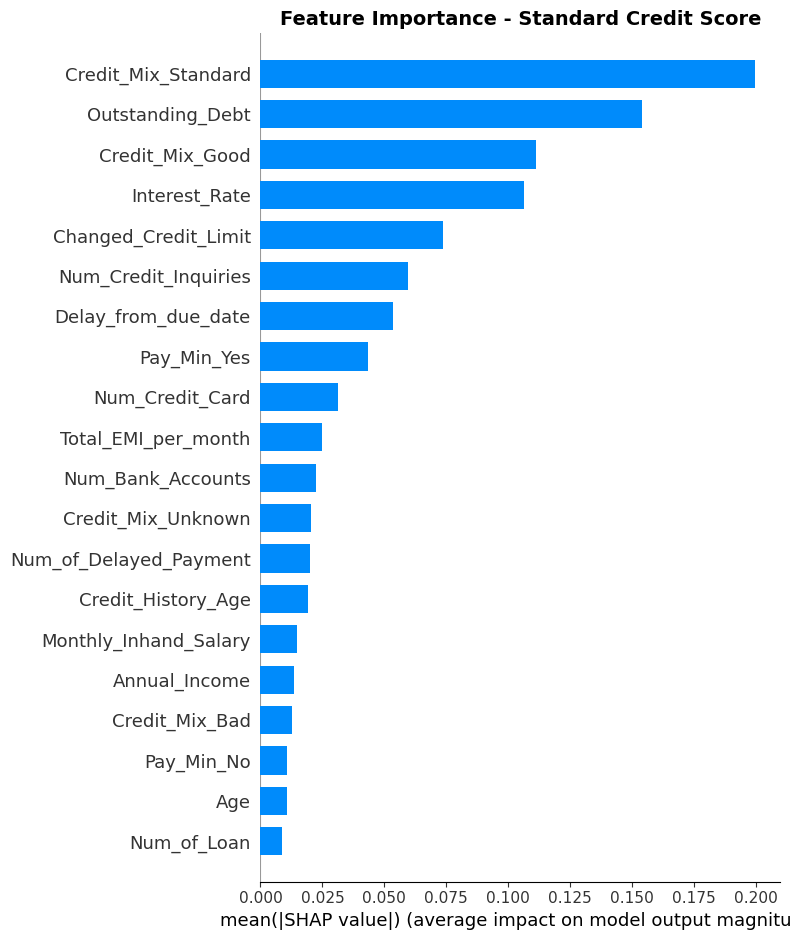

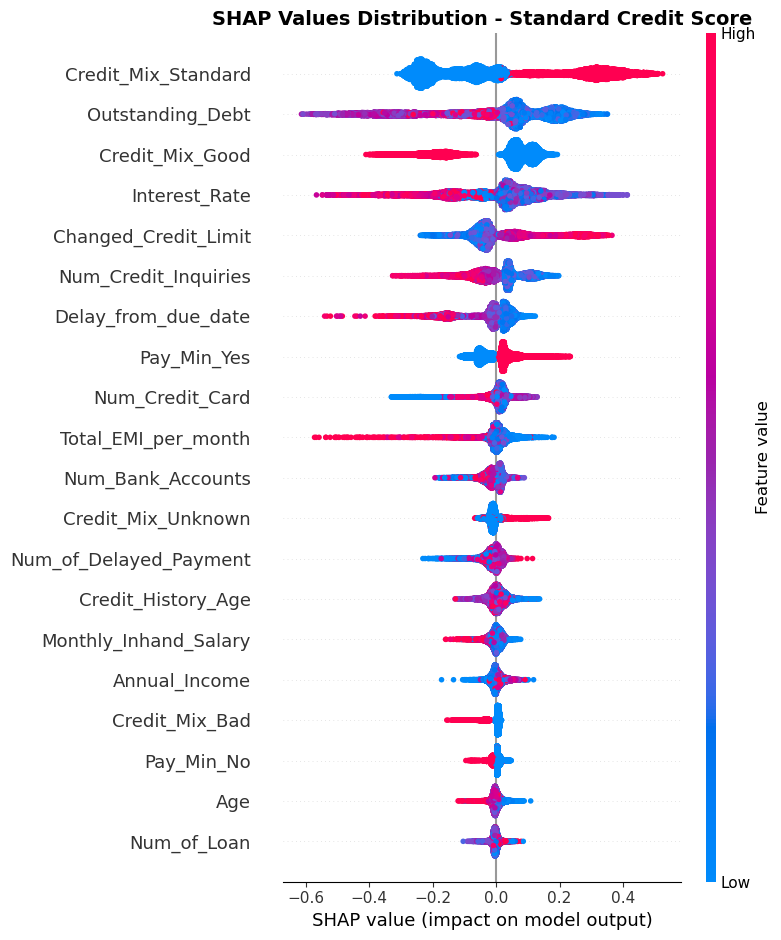

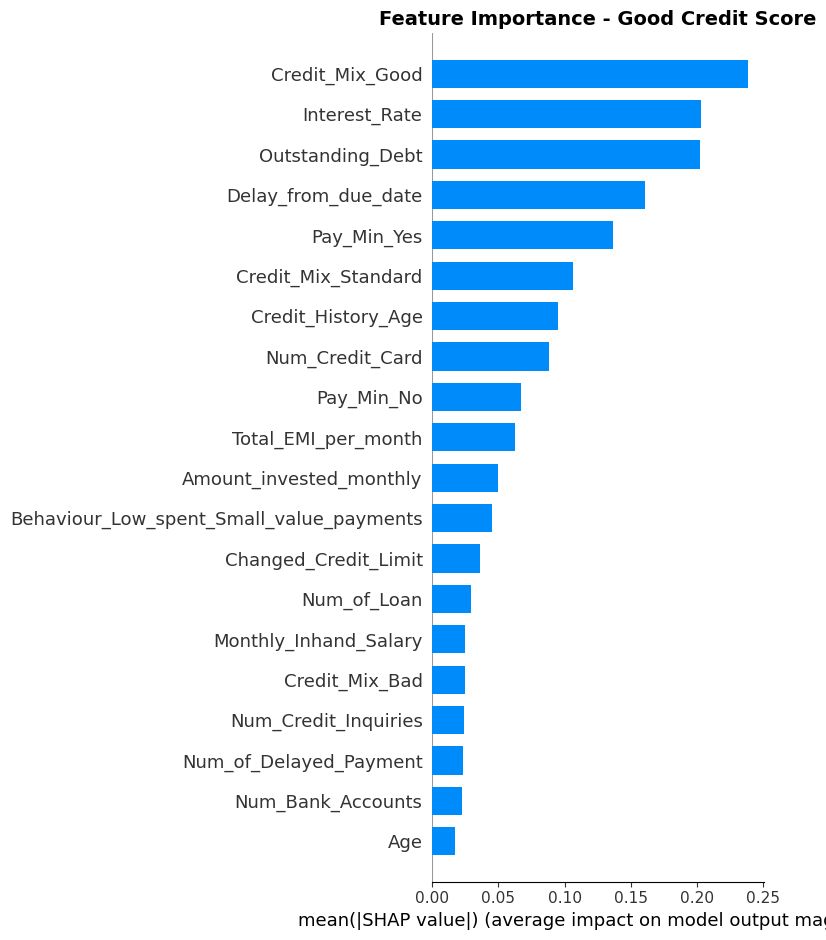

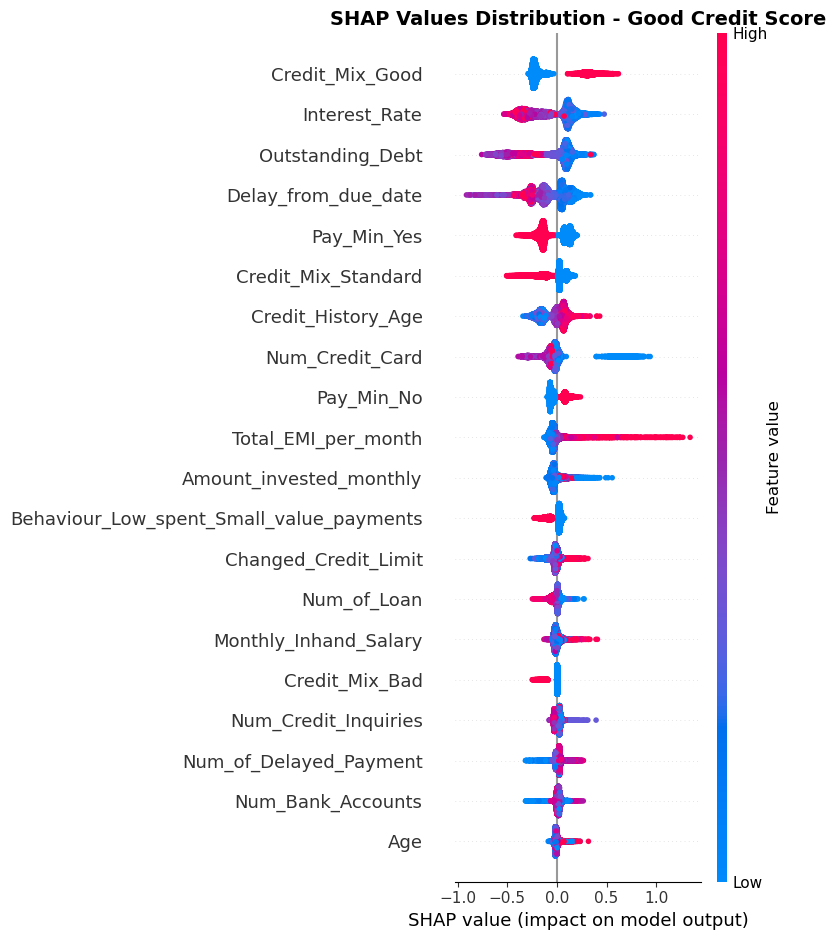

In [11]:
class_names = ['Poor', 'Standard', 'Good']

for i, class_name in enumerate(class_names):
    
    # Bar plot: importancia absoluta
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values[i], 
                     X_test,
                     plot_type="bar",
                     max_display=20,
                     show=False)
    plt.title(f'Feature Importance - {class_name} Credit Score', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Beeswarm plot: dirección del efecto
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values[i], 
                     X_test,
                     max_display=20,
                     show=False)
    plt.title(f'SHAP Values Distribution - {class_name} Credit Score', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### <font color = 'skyblue'> Selected Features

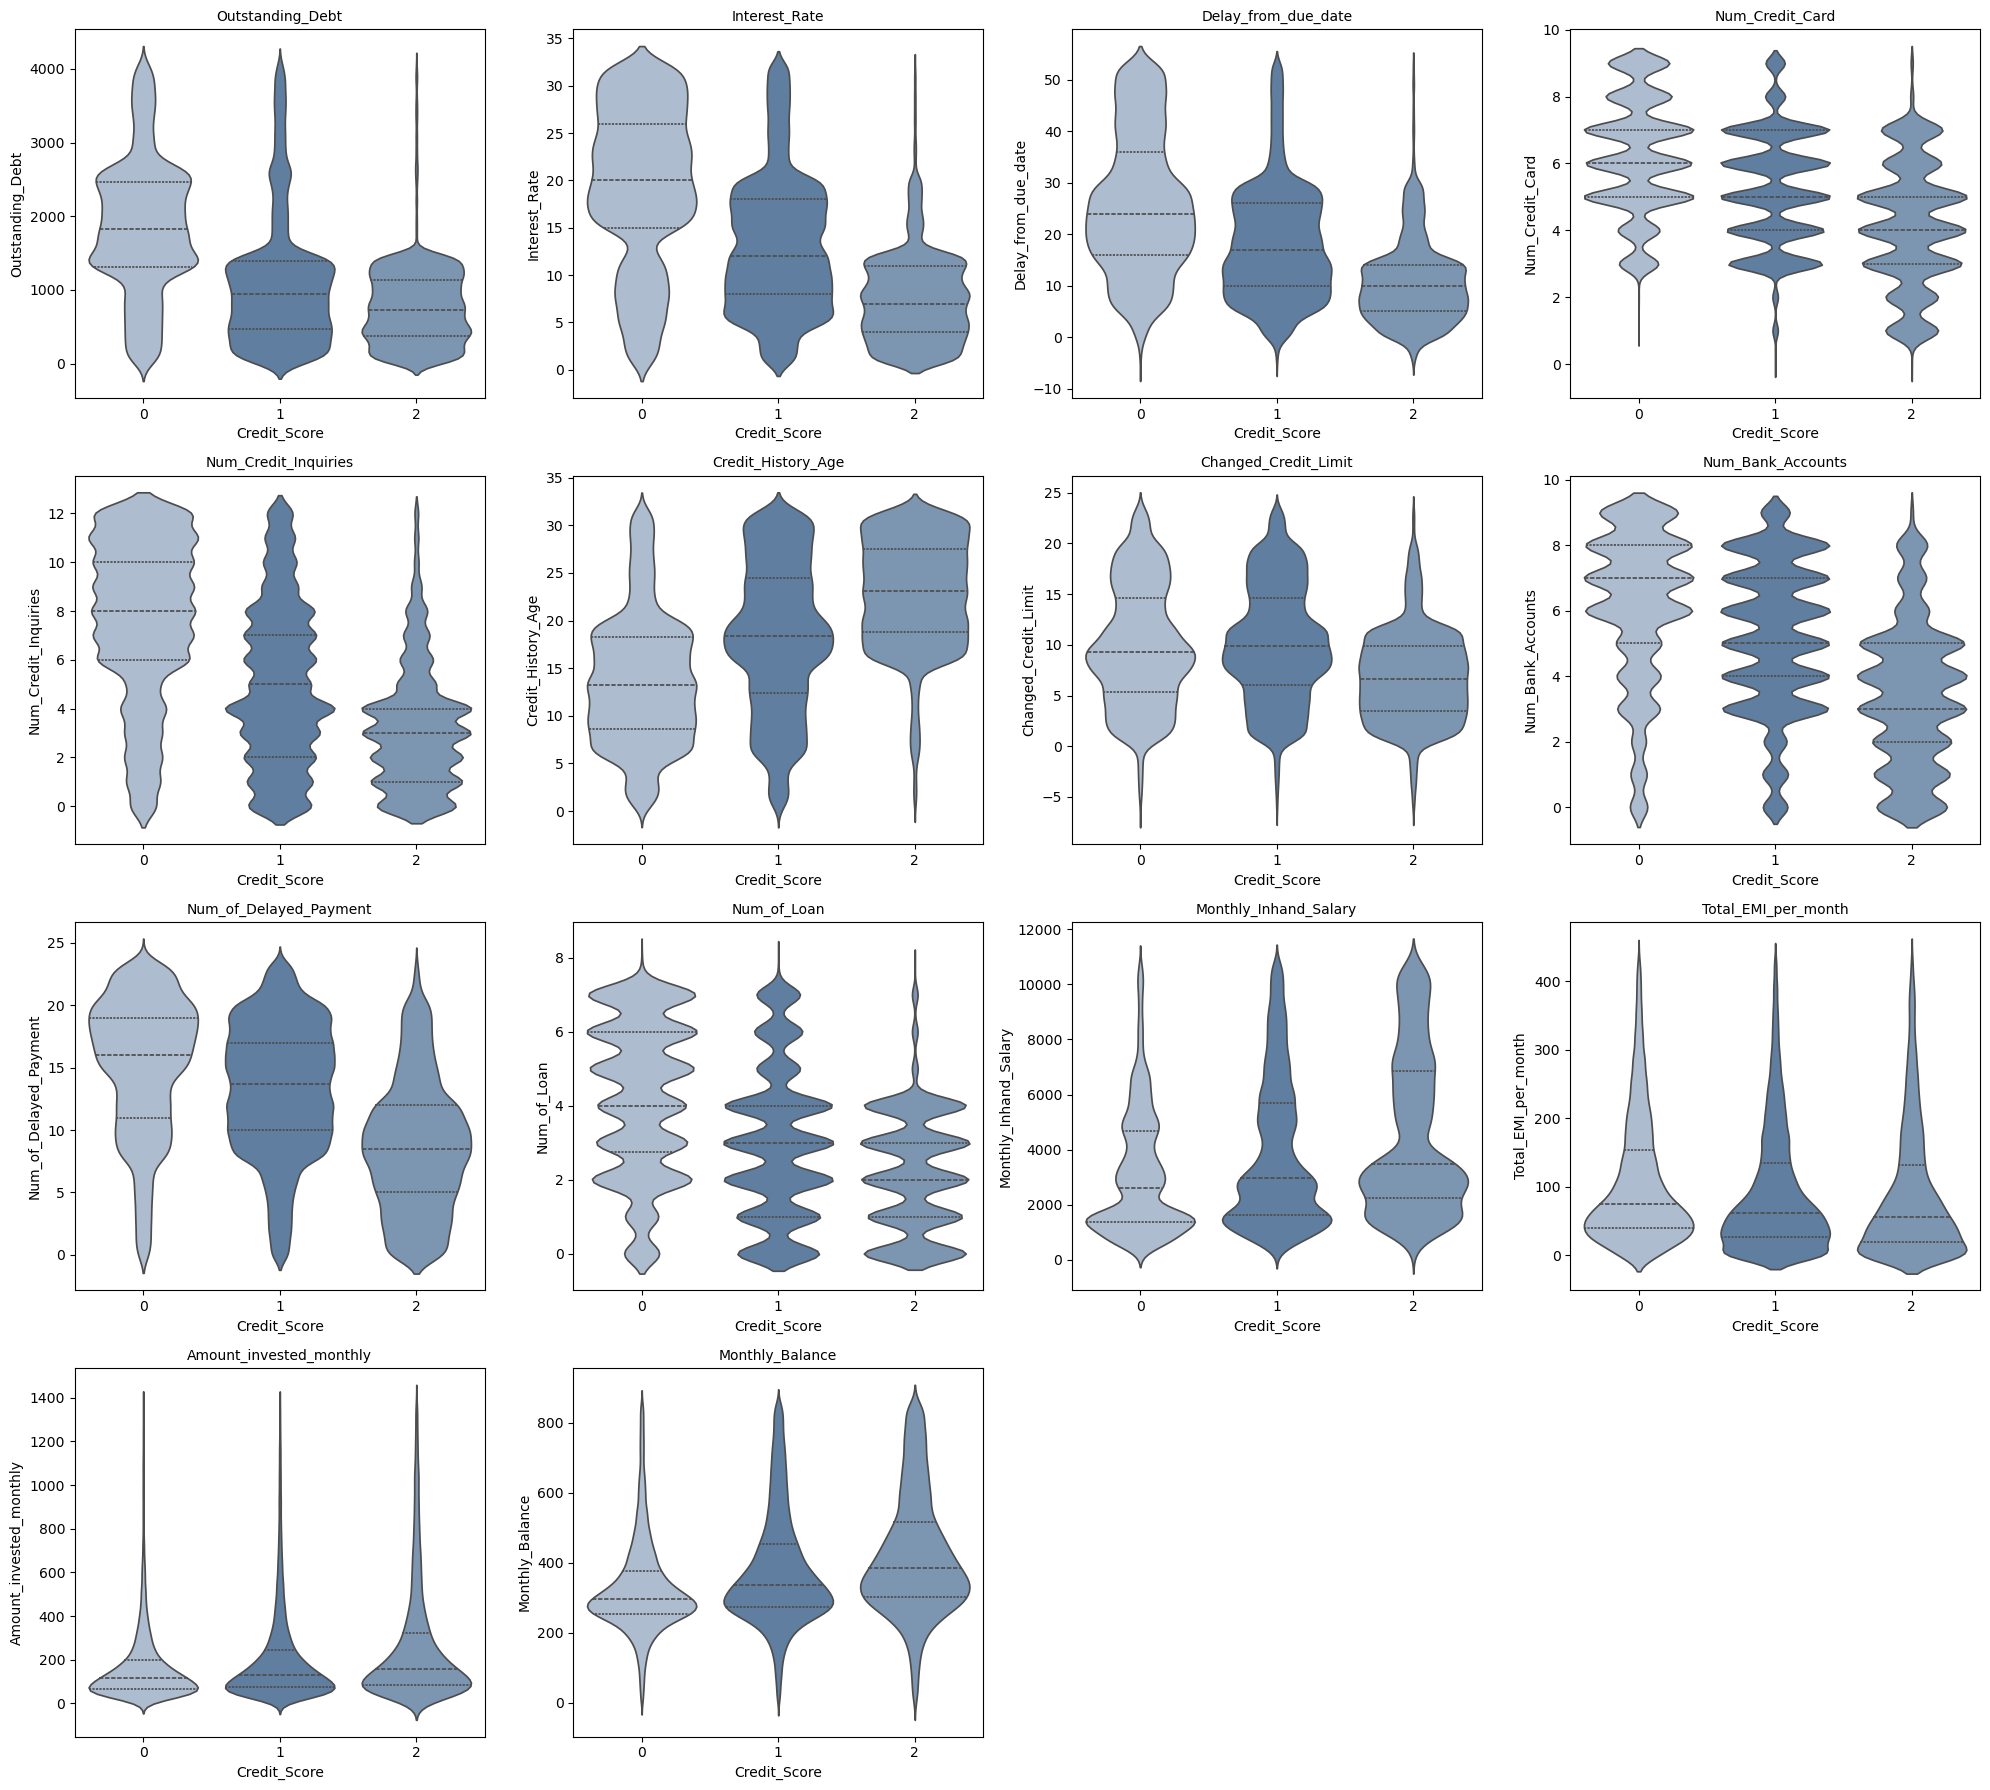

In [12]:
color_palette = ['#A7BCD4', '#547DAB', '#7394BA']

# To select the variables first we filter the top 20 most important features based on feature importance, shap values in general and shap values for people with 
# poor credit score (we consider more important to detect people with poor credit score given the default risk), then we pick the ones that appear in 2 out of 3.
variables = [
    'Outstanding_Debt',
    'Interest_Rate',
    'Delay_from_due_date',
    'Num_Credit_Card',
    'Num_Credit_Inquiries',
    'Credit_History_Age',
    'Changed_Credit_Limit',
    'Num_Bank_Accounts',
    'Num_of_Delayed_Payment',
    'Num_of_Loan',
    'Monthly_Inhand_Salary',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

n_cols = 4
n_rows = int(np.ceil(len(variables) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 18))
axes = axes.flatten()

# We filter by the 95th percentile to avoid outliers distorting the plots, but we keep all the data for the analysis. We look for clear patterns in the data distribution.
for i, var in enumerate(variables):
    
    data_filtered = data[data[var] < data[var].quantile(0.95)]
    
    sns.violinplot(
        data=data_filtered,
        x='Credit_Score',
        y=var,
        common_norm=False,
        inner='quartile',
        ax=axes[i],
        palette=color_palette
    )
    
    axes[i].set_title(var, fontsize=10)
    axes[i].tick_params(axis='x', rotation=0)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

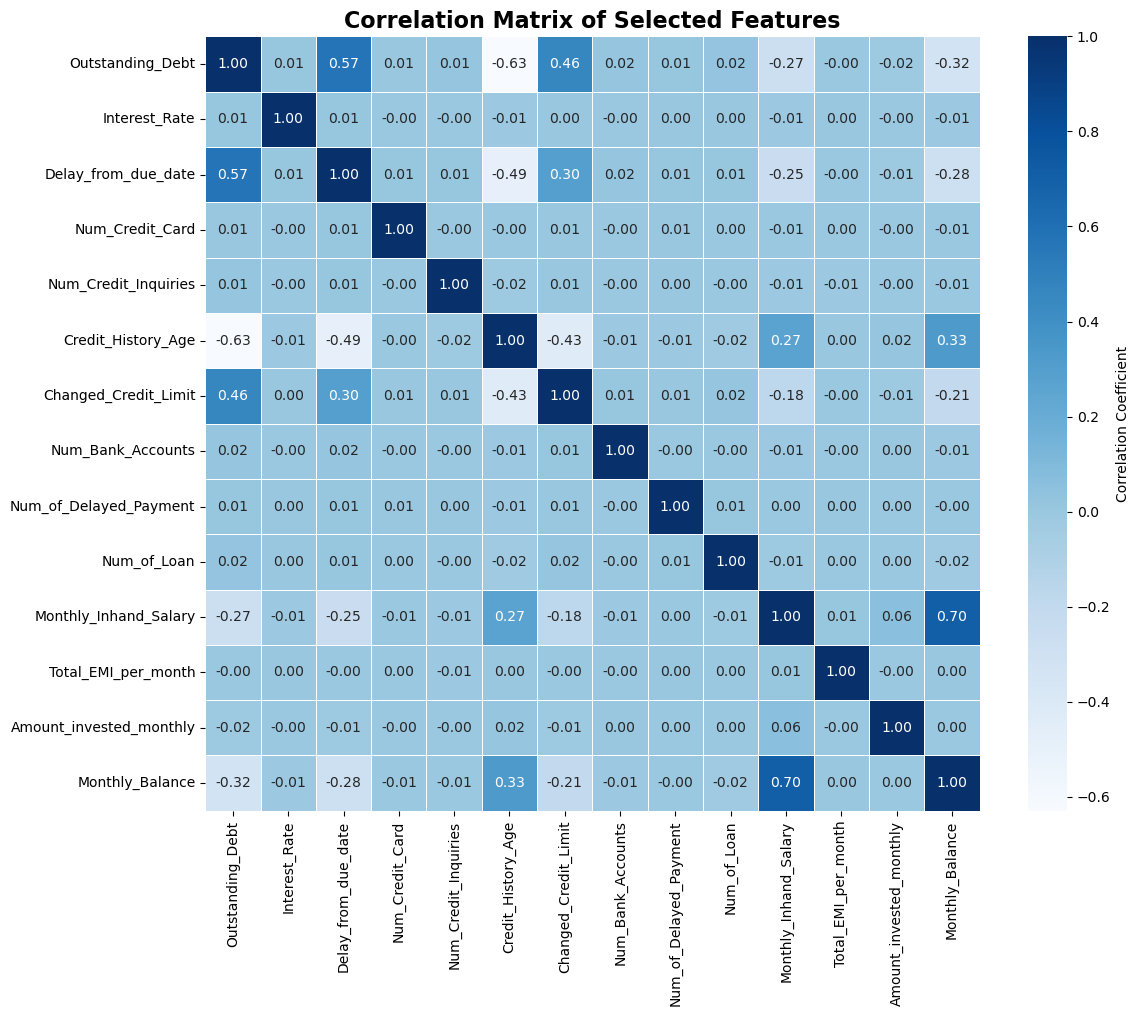

In [13]:
palette = sns.color_palette('Blues', as_cmap=True)

features_corr = data[variables]
corr_matrix = features_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", square=True, cmap=palette, linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Selected Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
variables_importances_xgboost = pd.DataFrame({
    'feature': X.columns,
    'importance_xgboost': model.feature_importances_,
}).sort_values(by='importance_xgboost', ascending=False)


var_importances = (variables_importances_xgboost
             .set_index('feature')
             .loc[variables]
             .sort_values(by='importance_xgboost', ascending=False))

var_importances

,importance_xgboost
feature,
Outstanding_Debt,0.032156
Interest_Rate,0.026707
Num_Credit_Card,0.017951
Delay_from_due_date,0.014050
Num_Credit_Inquiries,0.012550
Num_Bank_Accounts,0.010737
Changed_Credit_Limit,0.008125
Num_of_Loan,0.007435
Num_of_Delayed_Payment,0.006887


## <font color='royalblue'> Weights 

In [15]:
# We keep 3 binary varibles based on importance, and 10 numerical variables that appear in at least 2 out of 3 importance lists 
# (feature importance, shap values overall and shap values for poor credit score) and showed clear patterns between group distributions in the violin plots.
final_variables = [
    'Outstanding_Debt',
    'Interest_Rate',
    'Delay_from_due_date',
    'Num_Credit_Card',
    'Num_Credit_Inquiries',
    #'Credit_History_Age',
    'Num_Bank_Accounts',
    #'Num_of_Delayed_Payment',
    #'Monthly_Inhand_Salary',
    #'Age',
    'Pay_Min_Yes',
    'Pay_Min_No',
    #'Monthly_Balance',
    'Credit_Mix_Good',
    'Credit_Mix_Standard',
    #'Credit_Mix_Bad'
    #'Behaviour_Low_spent_Small_value_payments'
]

variables_importances_xgboost = pd.DataFrame({
    'feature': X.columns,
    'importance_xgboost': model.feature_importances_,
}).sort_values(by='importance_xgboost', ascending=False)

var_final = (variables_importances_xgboost
             .set_index('feature')
             .loc[final_variables])

var_final

,importance_xgboost
feature,
Outstanding_Debt,0.032156
Interest_Rate,0.026707
Delay_from_due_date,0.014050
Num_Credit_Card,0.017951
Num_Credit_Inquiries,0.012550
Num_Bank_Accounts,0.010737
Pay_Min_Yes,0.090979
Pay_Min_No,0.068036
Credit_Mix_Good,0.262000


In [16]:
scaler = StandardScaler()

X_train_filtered = X_train[final_variables]
X_test_filtered = X_test[final_variables]

X_train_scaled = scaler.fit_transform(X_train_filtered)
X_test_scaled = scaler.transform(X_test_filtered)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_filtered.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_filtered.columns)

X_train_scaled['Credit_Score'] = y_train.values
X_test_scaled['Credit_Score'] = y_test.values

all_data = pd.concat([X_train_scaled, X_test_scaled], axis=0)

In [17]:
# We invert the sign of the variables that have a negative relationship with the credit score to make the interpretation easier, so higher values always mean higher credit score.
negative_relationships = ['Outstanding_Debt', 'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Card', 'Num_Credit_Inquiries', 'Num_Bank_Accounts']

for var in negative_relationships:
    var_final.loc[var] = -var_final.loc[var]

weights = var_final['importance_xgboost']

## <font color='royalblue'> Scores 

In [18]:
# Filter tha dataframe to keep only the final variables and the target variable.
data_for_model = all_data[final_variables + ['Credit_Score']]
# Calculate the credit score as a weighted sum of the final variables using the importance values from the xgboost model as weights.
data_for_model['Score'] = np.dot(data_for_model[final_variables], weights)
data_for_model

,Outstanding_Debt,Interest_Rate,Delay_from_due_date,Num_Credit_Card,Num_Credit_Inquiries,Num_Bank_Accounts,Pay_Min_Yes,Pay_Min_No,Credit_Mix_Good,Credit_Mix_Standard,Credit_Score,Score
0,-0.553821,-0.140699,-0.609906,-0.142932,-0.143527,-0.096033,-1.046689,1.340379,-0.567708,-0.757810,1,-0.224294
1,-0.227865,-0.117172,0.466222,-0.127479,4.623098,-0.120915,0.955394,-0.746058,-0.567708,1.319592,1,0.023313
2,-0.505039,-0.119311,-0.071842,-0.142932,-0.122528,-0.104327,0.955394,-0.746058,-0.567708,1.319592,1,0.099501
3,-0.510508,-0.112894,0.466222,-0.119752,-0.143527,-0.104327,-1.046689,-0.746058,-0.567708,1.319592,0,-0.090355
4,-0.091541,-0.132143,-0.609906,-0.150658,-0.133027,-0.112621,-1.046689,1.340379,-0.567708,-0.757810,1,-0.239203
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,-0.561805,-0.138560,-0.811679,-0.119752,-0.138277,-0.104327,-1.046689,1.340379,-0.567708,-0.757810,1,-0.221653
19996,-0.328202,-0.151393,-0.609906,6.285483,-0.127778,-0.129209,-1.046689,1.340379,1.761469,-0.757810,2,0.263741
19997,-0.226223,-0.132143,-0.609906,-0.119752,-0.117279,-0.087738,0.955394,-0.746058,-0.567708,-0.757810,1,-0.195697
19998,2.849447,-0.082951,-0.139100,-0.135205,-0.106779,-0.096033,0.955394,-0.746058,-0.567708,-0.757810,1,-0.302292


In [19]:
# Filter the dataframe with the mdoel variables into train and test sets to evaluate the performance of the credit score as a predictor of the credit score groups.
train_results = data_for_model.iloc[:len(X_train)]

min_score = train_results['Score'].min()
max_score = train_results['Score'].max()

new_min = 0
new_max = 500

data_for_model['Score'] = (
    (data_for_model['Score'] - min_score) / (max_score - min_score)
) * (new_max - new_min) + new_min

test_results = data_for_model.iloc[len(X_train):]

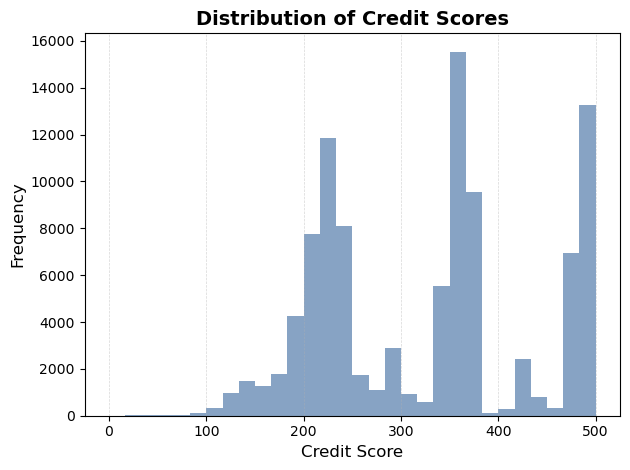

 Min Credit Score: 0.00
 Max Credit Score: 500.00


In [20]:
plt.hist(data_for_model['Score'], bins=30, color='#547DAB', alpha=0.7)
plt.title('Distribution of Credit Scores', fontsize=14, fontweight='bold')
plt.xlabel('Credit Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.grid(axis='x', alpha=0.5, linestyle='--', linewidth=0.5)
plt.show()

print(f' Min Credit Score: {data_for_model["Score"].min():.2f}')
print(f' Max Credit Score: {data_for_model["Score"].max():.2f}')

## <font color='royalblue'> Optimizing Thresholds 

In [21]:
scores = test_results['Score'].values
true_labels = test_results['Credit_Score'].values

min_score = scores.min()
max_score = scores.max()

def objective(trial):
    
    t1 = trial.suggest_int("t1", min_score, max_score)
    t2 = trial.suggest_int("t2", t1, max_score)
    
    preds = np.where(scores < t1, 0,
             np.where(scores < t2, 1, 2))
    
    acc = (preds == true_labels).mean()
    
    return acc

study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=500,
    show_progress_bar=True,

)

print("Best thresholds:", study.best_params)
print("Best accuracy:", study.best_value)

  0%|          | 0/500 [00:00<?, ?it/s]

Best thresholds: {'t1': 235, 't2': 409}
Best accuracy: 0.59475


In [22]:
# Establish the thresholds for the credit score groups based on the optimization results (The selected values were the most repeated across different trials)
t1 = 235
t2 = 412

# Map the calculated score to the original classification (0,1,2) in order to compute relevant classification metrics
test_results['Calculated_Score'] = test_results['Score'].apply(lambda x: 0 if x < t1 else (1 if x < t2 else 2))
test_results

,Outstanding_Debt,Interest_Rate,Delay_from_due_date,Num_Credit_Card,Num_Credit_Inquiries,Num_Bank_Accounts,Pay_Min_Yes,Pay_Min_No,Credit_Mix_Good,Credit_Mix_Standard,Credit_Score,Score,Calculated_Score
0,2.739053,-0.089367,-0.273616,-0.112026,-0.080531,-0.062856,0.955394,-0.746058,-0.567708,-0.757810,1,202.907926,0
1,-0.105884,-0.153531,-0.744421,-0.127479,-0.122528,-0.104327,-1.046689,1.340379,1.761469,-0.757810,1,479.574024,2
2,0.049595,-0.100061,0.735254,-0.096573,-0.080531,-0.087738,0.955394,-0.746058,-0.567708,1.319592,0,353.815669,1
3,1.096785,-0.106478,2.214930,-0.112026,-0.112029,-0.087738,0.955394,-0.746058,-0.567708,-0.757810,1,210.725715,0
4,-0.101062,-0.110755,1.878640,-0.135205,-0.096280,-0.087738,0.955394,-0.746058,-0.567708,-0.757810,0,228.689873,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,-0.561805,-0.138560,-0.811679,-0.119752,-0.138277,-0.104327,-1.046689,1.340379,-0.567708,-0.757810,1,234.292649,0
19996,-0.328202,-0.151393,-0.609906,6.285483,-0.127778,-0.129209,-1.046689,1.340379,1.761469,-0.757810,2,434.396812,2
19997,-0.226223,-0.132143,-0.609906,-0.119752,-0.117279,-0.087738,0.955394,-0.746058,-0.567708,-0.757810,1,244.993075,1
19998,2.849447,-0.082951,-0.139100,-0.135205,-0.106779,-0.096033,0.955394,-0.746058,-0.567708,-0.757810,1,201.048897,0


In [23]:
# Comparing original class distribution against the predicted one
test_results['Credit_Score'].value_counts()
percentages = test_results['Credit_Score'].value_counts(normalize=True) * 100

test_results['Calculated_Score'].value_counts()
percentages_calculated = test_results['Calculated_Score'].value_counts(normalize=True) * 100

print("\nOriginal Distribution:")
print("-" * 30)
for label, pct in percentages.sort_index().items():
    print(f"  Class {label}: {pct:>6.2f}%")

print("\nPredicted Distribution:")
print("-" * 30)
for label, pct in percentages_calculated.sort_index().items():
    print(f"  Class {label}: {pct:>6.2f}%")


Original Distribution:
------------------------------
  Class 0:  28.99%
  Class 1:  53.17%
  Class 2:  17.83%

Predicted Distribution:
------------------------------
  Class 0:  30.96%
  Class 1:  45.36%
  Class 2:  23.68%


## <font color='royalblue'> Results

              precision    recall  f1-score   support

           0       0.51      0.54      0.52      5799
           1       0.71      0.60      0.65     10635
           2       0.50      0.66      0.57      3566

    accuracy                           0.59     20000
   macro avg       0.57      0.60      0.58     20000
weighted avg       0.61      0.59      0.60     20000



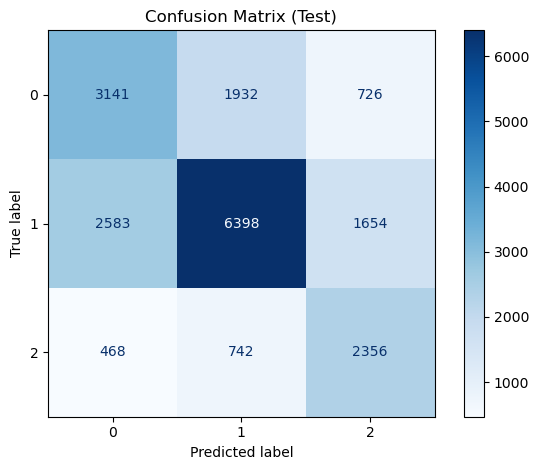

In [24]:
# Evaluation
print(classification_report(test_results['Credit_Score'], test_results['Calculated_Score']))

ConfusionMatrixDisplay.from_predictions(
    test_results['Credit_Score'], test_results['Calculated_Score'],
    display_labels=[0, 1, 2],
    cmap='Blues'
)
plt.title('Confusion Matrix (Test)')

plt.tight_layout()
plt.show()

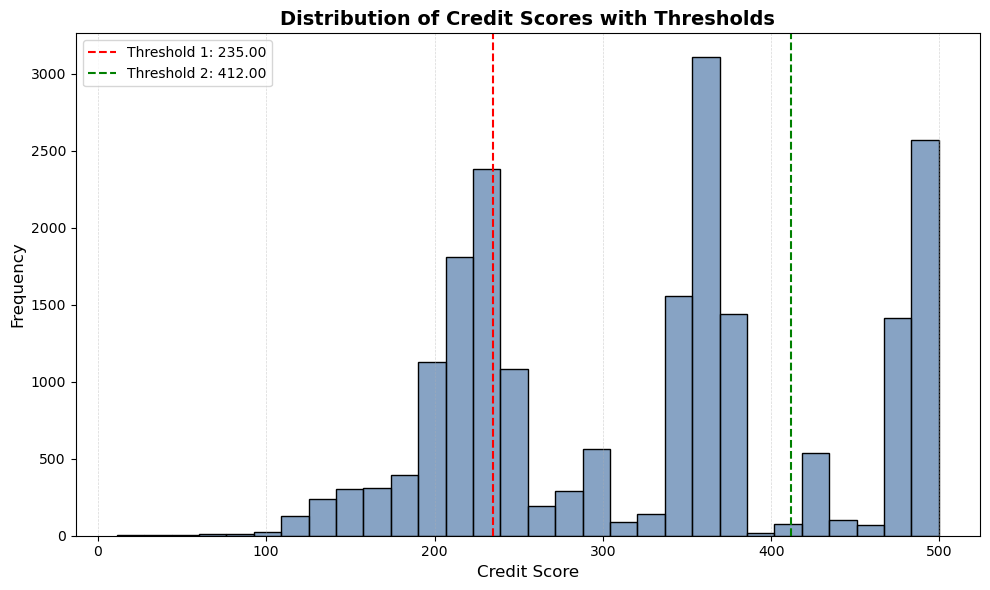

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(test_results['Score'], bins=30, color='#547DAB', alpha=0.7)
plt.axvline(x=t1, color='red', linestyle='--', label=f'Threshold 1: {t1:.2f}')
plt.axvline(x=t2, color='green', linestyle='--', label=f'Threshold 2: {t2:.2f}')
plt.title('Distribution of Credit Scores with Thresholds', fontsize=14, fontweight='bold')
plt.xlabel('Credit Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.grid(axis='x', alpha=0.5, linestyle='--', linewidth=0.5)
plt.show()

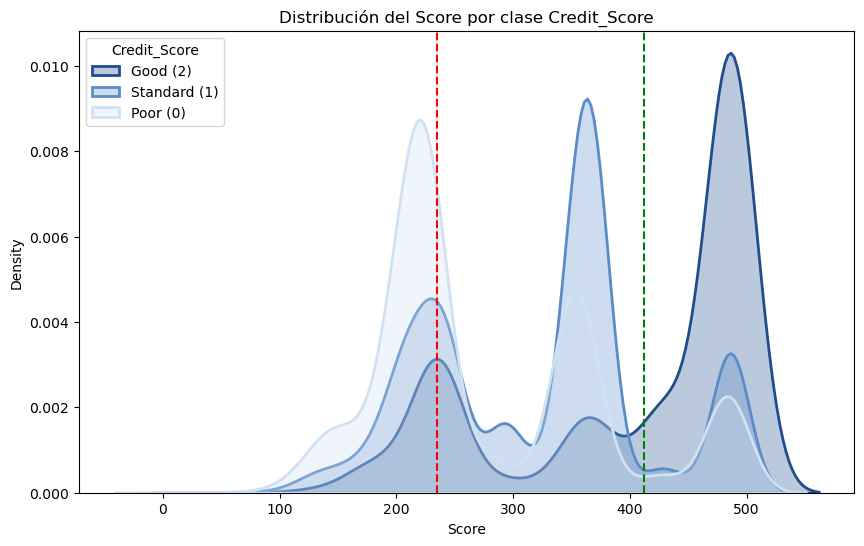

In [26]:
plt.figure(figsize=(10,6))

new_colors = ['#CFE1F2', '#5A8CC8', '#1F4E8C']
sns.kdeplot(
    data=test_results,
    x="Score",
    hue="Credit_Score",
    fill=True,
    alpha=0.3,
    common_norm=False,
    linewidth=2,
    palette=new_colors,
)

plt.axvline(x=t1, color='red', linestyle='--', label=f'Threshold 1: {t1}')
plt.axvline(x=t2, color='green', linestyle='--', label=f'Threshold 2: {t2}')

plt.xlabel("Score")
plt.ylabel("Density")
plt.title("Distribución del Score por clase Credit_Score")
plt.legend(title="Credit_Score", labels=['Good (2)', 'Standard (1)', 'Poor (0)'])
plt.show()

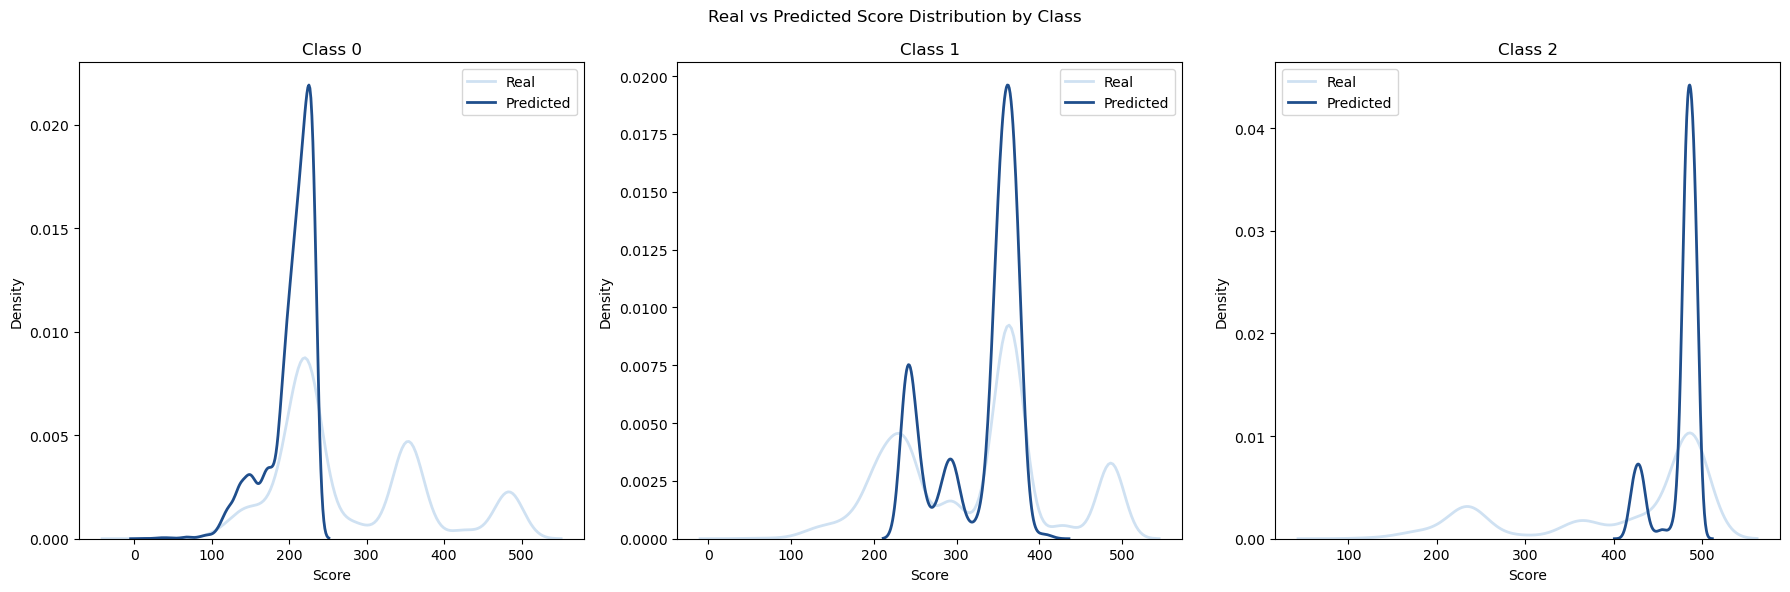

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=False)

for i, c in enumerate([0,1,2]):
    
    sns.kdeplot(
        test_results[test_results['Credit_Score']==c]['Score'],
        ax=axes[i],
        label='Real',
        linewidth=2,
        common_norm=False,
        color='#CFE1F2'
    )
    
    sns.kdeplot(
        test_results[test_results['Calculated_Score']==c]['Score'],
        ax=axes[i],
        label='Predicted',
        linewidth=2,
        common_norm=False,
        color='#1F4E8C'
    )
    
    axes[i].set_title(f'Class {c}')
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.suptitle("Real vs Predicted Score Distribution by Class")
plt.tight_layout()
plt.show()

## <font color='royalblue'> Model Use

In [28]:
def score(data: pd.DataFrame):

    # This are the names for the original variables in the dataset
    original_variables = ['Outstanding_Debt',
                        'Interest_Rate',
                        'Delay_from_due_date',
                        'Num_Credit_Card',
                        'Num_Credit_Inquiries',
                        'Num_Bank_Accounts',
                        'Payment_of_Min_Amount',
                        'Credit_Mix']
    
    # Name of the variables after the preproccesing steps. This is in case the data used is already cleaned according to our standards
    modified_variables = ['Outstanding_Debt',
                        'Interest_Rate',
                        'Delay_from_due_date',
                        'Num_Credit_Card',
                        'Num_Credit_Inquiries',
                        'Num_Bank_Accounts',
                        'Pay_Min_Yes',
                        'Pay_Min_No',
                        'Credit_Mix_Good',
                        'Credit_Mix_Standard']
    
    # The weights corresponding to each variables with the name after the preproccesing steps
    weights = {'Outstanding_Debt':  -0.032156,
               'Interest_Rate': -0.026707,
               'Delay_from_due_date': -0.014050,
               'Num_Credit_Card': -0.017951,
               'Num_Credit_Inquiries': -0.012550,
               'Num_Bank_Accounts': -0.010737,
               'Pay_Min_Yes': 0.090979,
               'Pay_Min_No': 0.068036,
               'Credit_Mix_Good': 0.262000,
               'Credit_Mix_Standard': 0.141270}
    
    # We also need the scaling parameters to standardize the data before applying the weights. (Train data params)
    scaling_params_dict = {'Mean': {'Outstanding_Debt': 1428.19890975,
                                    'Interest_Rate': 72.783925,
                                    'Delay_from_due_date': 21.06815,
                                    'Num_Credit_Card': 22.4989875,
                                    'Num_Credit_Inquiries': 27.340539888017652,
                                    'Num_Bank_Accounts': 17.578290306349878,
                                    'Pay_Min_Yes': 0.5228,
                                    'Pay_Min_No': 0.357575,
                                    'Credit_Mix_Good': 0.2437375,
                                    'Credit_Mix_Standard': 0.3647875},
                            'Std': {'Outstanding_Debt': 1157.393198340802,
                                    'Interest_Rate': 467.5523856067835,
                                    'Delay_from_due_date': 14.868122967526869,
                                    'Num_Credit_Card': 129.42537366751097,
                                    'Num_Credit_Inquiries': 190.49119900975955,
                                    'Num_Bank_Accounts': 120.5663495588871,
                                    'Pay_Min_Yes': 0.49947988948505223,
                                    'Pay_Min_No': 0.47928605172172495,
                                    'Credit_Mix_Good': 0.42933615162684596,
                                    'Credit_Mix_Standard': 0.4813705224084146}}
    
    # Values for scaling the final score to a 0-500 range
    min_score = -0.7899777238287378
    max_score = 0.42287501409236394
    
    # Thresholds for classification
    t1 = 235
    t2 = 412

    # Check if data has original variables (before preprocessing)
    if all(var in data.columns for var in original_variables):
        # Data needs preprocessing
        data = data[original_variables].copy()
        
        # Create dummy variables
        data = pd.get_dummies(data, columns=['Payment_of_Min_Amount', 'Credit_Mix'], prefix=['Pay_Min', 'Credit_Mix'])
        
        # Drop unwanted dummy categories
        cols_to_drop = ['Credit_Mix_Bad', 'Pay_Min_NM']
        # Filter only existing columns to drop
        cols_to_drop = [col for col in cols_to_drop if col in data.columns]
        if cols_to_drop:
            data.drop(columns=cols_to_drop, inplace=True)
        
        # Handle the underscore variant if it exists
        if 'Credit_Mix__' in data.columns:
            data.drop(columns=['Credit_Mix__'], inplace=True)
        if 'Credit_Mix_Unknown' in data.columns:
            data.drop(columns=['Credit_Mix_Unknown'], inplace=True)
    
    # Check if data already has modified variables (after preprocessing)
    elif all(var in data.columns for var in modified_variables):
        # Data is already preprocessed, just select the columns
        data = data[modified_variables].copy()
    
    else:
        # Neither original nor modified variables are present
        missing_original = [var for var in original_variables if var not in data.columns]
        missing_modified = [var for var in modified_variables if var not in data.columns]
        raise ValueError(
            f"Input data doesn't match expected format.\n"
            f"Missing original variables: {missing_original}\n"
            f"Missing modified variables: {missing_modified}"
        )
    
    # Reorder columns to match weights order
    data = data[weights.keys()]
    
    # Standardize using pre-computed scaling parameters
    for col in data.columns:
        if col in scaling_params_dict['Mean']:
            data[col] = (data[col] - scaling_params_dict['Mean'][col]) / scaling_params_dict['Std'][col]
    
    # Calculate raw score using dot product
    score = np.dot(data, list(weights.values()))
    
    # Scale to 0-500 range
    score = ((score - min_score) / (max_score - min_score)) * 500
    
    # Classify based on thresholds
    classification = np.where(score < t1, 0, np.where(score < t2, 1, 2))

    # Credit Category Mapping
    category_mapping = {0: 'Poor', 1: 'Standard', 2: 'Good'}
    
    # Add results to dataframe
    data['Score'] = score
    data['Classification'] = classification
    data['Credit_Category'] = data['Classification'].map(category_mapping)

    return data[['Score', 'Classification', 'Credit_Category']]

In [29]:
# We import data that has the origibal variables names
# This is to test the filtering and data preprocessing steps of the function, as well as the score calculation and classification.
# The function will also be tested with already clean data to ensure everything works as expected in both scenarios.
df = pd.read_csv('trial_data.csv')

In [30]:
# This is for non-modified data with original variable names, the function should preprocess it and calculate the score and classification correctly.
display(score(df))
# This is for already modified data, the function should calculate the score and classification correctly without needing to preprocess the data.
# Note: Both results should be the same given that the data is the same, just with different variable names.
display(score(data))

,Score,Classification,Credit_Category
0,236.544640,1,Standard
1,489.676913,2,Good
2,488.118645,2,Good
3,487.339511,2,Good
4,486.949944,2,Good
...,...,...,...
99995,232.058335,0,Poor
99996,234.006170,0,Poor
99997,347.331568,1,Standard
99998,484.801041,2,Good


,Score,Classification,Credit_Category
0,236.544640,1,Standard
1,489.676913,2,Good
2,488.118645,2,Good
3,487.339511,2,Good
4,486.949944,2,Good
...,...,...,...
99995,232.058335,0,Poor
99996,234.006170,0,Poor
99997,347.331568,1,Standard
99998,484.801041,2,Good
